classification

In [10]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import shutil
import os


Download Dataset

In [ ]:
#https://poe.com/s/TxOgAOgVlFIMRJt9Xuhs

# --- 1. Define Variables ---
# Get the dataset handle from the dataset's URL on Kaggle
# Example: 'muratkokludataset/rice-image-dataset'
dataset_handle = "muratkokludataset/rice-image-dataset"

# Your desired final path to store the dataset
destination_path = "/home/sajad/Sajad_test/dataset"

print(f"Starting process for dataset: {dataset_handle}")

# --- 2. Download the Dataset using kagglehub ---
# This command downloads the dataset to the Kaggle cache folder and returns its path.
try:
    print("Step 1: Downloading dataset from Kaggle...")
    download_path = kagglehub.dataset_download(dataset_handle)
    print(f"Download successful. Temporary path: {download_path}")
except Exception as e:
    print(f"Error downloading dataset: {e}")
    exit()

# --- 3. Create the Destination Folder (if it doesn't exist) ---
print(f"Step 2: Preparing destination path: {destination_path}")
os.makedirs(destination_path, exist_ok=True)

# --- 4. Move Contents from Download Path to Destination ---
# shutil.move acts like a Cut-Paste operation.
try:
    print("Step 3: Moving files to final destination...")
    # Get the base name of the downloaded folder
    source_folder_name = os.path.basename(download_path)
    final_destination = os.path.join(destination_path, source_folder_name)

    # If the folder already exists at the destination, remove it first to prevent errors.
    if os.path.exists(final_destination):
        shutil.rmtree(final_destination)
        print(f"Removed existing folder at destination: {final_destination}")

    shutil.move(download_path, destination_path)
    print("✅ Move completed successfully!")
    print(f"Your dataset is now located at: {final_destination}")
except Exception as e:
    print(f"Error moving files: {e}")


Starting process for dataset: muratkokludataset/rice-image-dataset
Step 1: Downloading dataset from Kaggle...


Download successful. Temporary path: /home/sajad/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1
Step 2: Preparing destination path: /home/sajad/Sajad_test/dataset
Step 3: Moving files to final destination...
✅ Move completed successfully!
Your dataset is now located at: /home/sajad/Sajad_test/dataset/1


The number of class - Visualization

In [ ]:
#https://poe.com/s/9MNupX21WHumOsxUqg1l
# Show in HTML for reporting
import os
import random
import base64
import webbrowser
from datetime import datetime

# --- Configuration ---
main_directory_path = '/home/sajad/Sajad_test/dataset/1/Rice_Image_Dataset'
output_html_file = 'dataset_report.html'
samples_per_class = 5

# --- HTML Template ---
HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="fa" dir="rtl">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>گزارش تحلیل دیتاست</title>
    <style>
        @import url('https://fonts.googleapis.com/css2?family=Vazirmatn:wght@400;600&display=swap');
        body {{ font-family: 'Vazirmatn', sans-serif; background-color: #f4f7f6; color: #333; margin: 0; padding: 20px; }}
        .container {{ max-width: 1200px; margin: auto; background: #fff; padding: 30px; border-radius: 10px; box-shadow: 0 4px 15px rgba(0,0,0,0.07); }}
        h1, h2, h3 {{ color: #0056b3; }}
        h1 {{ text-align: center; border-bottom: 2px solid #007bff; padding-bottom: 15px; }}
        h1 small {{ font-size: 0.6em; color: #6c757d; display: block; margin-top: 5px; }}
        table {{ width: 100%; border-collapse: collapse; margin: 30px 0; direction: ltr; }}
        th, td {{ border: 1px solid #dee2e6; padding: 12px; text-align: left; }}
        th {{ background-color: #e9ecef; }}
        .total-row {{ font-weight: bold; background-color: #f8f9fa; }}
        .class-gallery {{ margin-bottom: 40px; border-top: 1px solid #eee; padding-top: 20px; }}
        .image-container {{ display: flex; flex-wrap: wrap; gap: 20px; justify-content: center; }}
        .image-card {{ border: 1px solid #ddd; border-radius: 8px; padding: 10px; text-align: center; background-color: #fafafa; width: 180px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); }}
        .image-card img {{ max-width: 100%; height: 150px; object-fit: cover; border-radius: 6px; }}
        .image-card p {{ margin: 10px 0 0; font-size: 0.8em; color: #555; word-wrap: break-word; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>گزارش تحلیل دیتاست<small>ایجاد شده در: {generation_date}</small></h1>
        <h2>📊 توزیع داده‌ها در کلاس‌ها</h2>
        {analysis_table}
        <h2>🖼️ نمونه تصاویر از هر کلاس</h2>
        {image_gallery}
    </div>
</body>
</html>
"""

def get_image_base64(image_path):
    """Reads an image file and returns its Base64 encoded string."""
    try:
        with open(image_path, "rb") as img_file:
            return base64.b64encode(img_file.read()).decode('utf-8')
    except Exception as e:
        print(f"Error reading {image_path}: {e}")
        return None

def generate_report(main_path, output_file):
    if not os.path.isdir(main_path):
        print(f"Error: Directory not found at '{main_path}'")
        return

    class_data = {}
    total_files = 0

    # 1. Collect data about all classes
    for class_name in sorted(os.listdir(main_path)):
        class_path = os.path.join(main_path, class_name)
        if os.path.isdir(class_path):
            files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
            num_files = len(files)
            if num_files > 0:
                class_data[class_name] = {'count': num_files, 'files': files, 'path': class_path}
                total_files += num_files

    # 2. Build the analysis table HTML
    table_html = "<table><tr><th>Class Name</th><th>Number of Images</th></tr>"
    for class_name, data in class_data.items():
        table_html += f"<tr><td>{class_name}</td><td>{data['count']}</td></tr>"
    table_html += f"<tr class='total-row'><td>Total Classes / Images</td><td>{len(class_data)} / {total_files}</td></tr>"
    table_html += "</table>"

    # 3. Build the image gallery HTML
    gallery_html = ""
    for class_name, data in class_data.items():
        gallery_html += f"<div class='class-gallery'><h3>کلاس: {class_name}</h3>"
        gallery_html += "<div class='image-container'>"
        
        sample_files = random.sample(data['files'], min(samples_per_class, data['count']))
        
        for img_file in sample_files:
            img_path = os.path.join(data['path'], img_file)
            base64_img = get_image_base64(img_path)
            if base64_img:
                file_ext = os.path.splitext(img_file)[1].lower().replace('.', '')
                if file_ext == 'jpg': file_ext = 'jpeg'
                gallery_html += f"""
                <div class='image-card'>
                    <img src='data:image/{file_ext};base64,{base64_img}' alt='{img_file}'>
                    <p>{img_file}</p>
                </div>
                """
        gallery_html += "</div></div>"

    # 4. Assemble the final HTML and write to file
    generation_date = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    final_html = HTML_TEMPLATE.format(
        generation_date=generation_date,
        analysis_table=table_html,
        image_gallery=gallery_html
    )
    
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(final_html)
    
    print(f"Report generated successfully: {output_file}")

    # 5. Open the report in the default web browser
    file_path = os.path.realpath(output_file)
    webbrowser.open('file://' + file_path)

# --- Run the analysis ---
if __name__ == "__main__":
    generate_report(main_directory_path, output_html_file)


Report generated successfully: dataset_report.html


Analyzing directory: /home/sajad/Sajad_test/dataset/1/Rice_Image_Dataset

--- Dataset Class Distribution ---
Class Name                | Number of Images
---------------------------------------------
Arborio                   | 15000
Basmati                   | 15000
Ipsala                    | 15000
Jasmine                   | 15000
Karacadag                 | 15000
---------------------------------------------
Total Classes:            | 5
Total Images:             | 75000
----------------------------------

Displaying image samples...


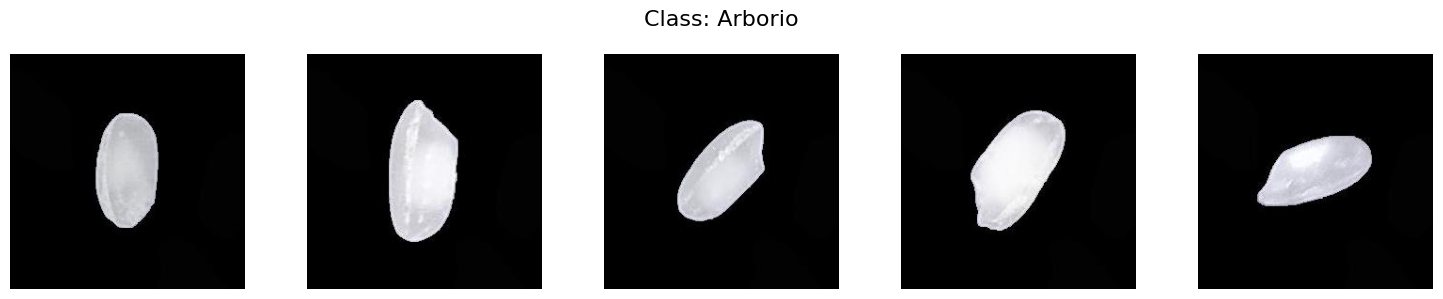

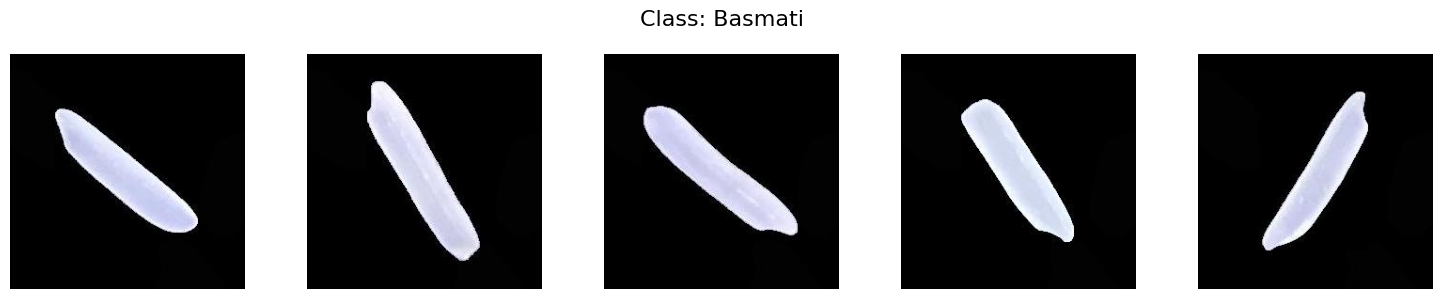

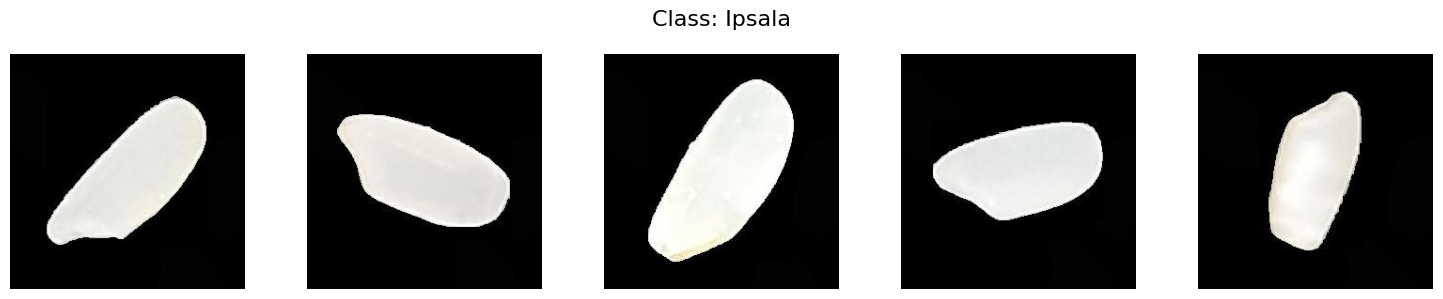

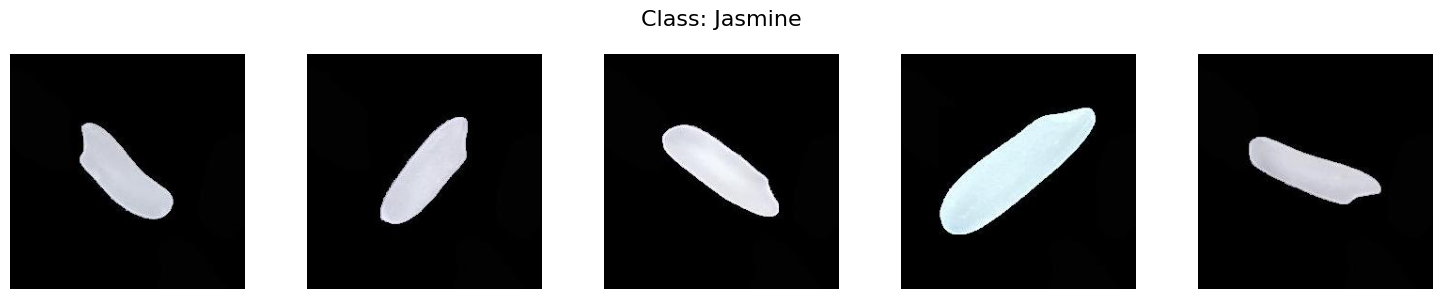

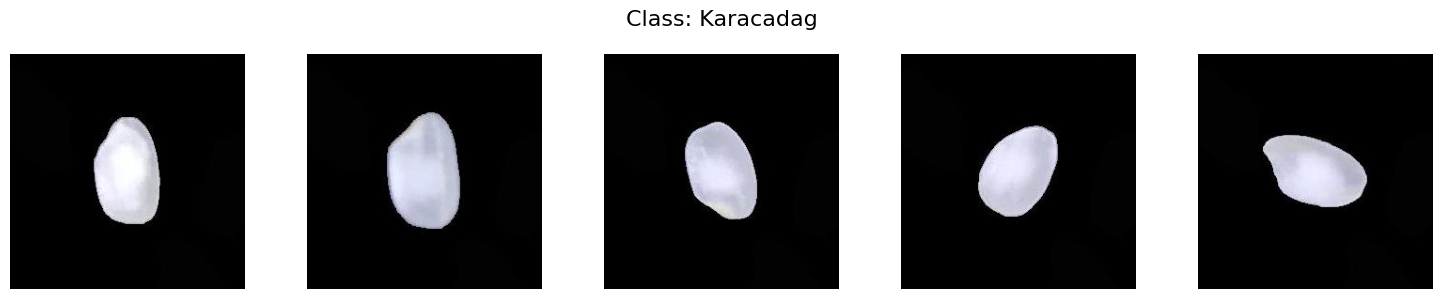

In [ ]:
#https://poe.com/s/VrGHXwgUhIgXUQrSnLjl
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# --- Configuration ---
# !!! IMPORTANT: Replace this with the path to your dataset folder.
main_directory_path = '/home/sajad/Sajad_test/dataset/1/Rice_Image_Dataset'
samples_per_class = 5

def analyze_and_visualize_dataset(main_path, num_samples):
    """
    Analyzes file distribution and displays random image samples for each class.
    """
    print(f"Analyzing directory: {main_path}\n")

    # Check if the provided path is a valid directory
    if not os.path.isdir(main_path):
        print(f"Error: The path '{main_path}' is not a valid directory.")
        return

    class_counts = {}
    class_files = {}
    total_files = 0

    # --- 1. Collect file counts and paths ---
    for class_name in sorted(os.listdir(main_path)):
        class_path = os.path.join(main_path, class_name)
        
        if os.path.isdir(class_path):
            files = os.listdir(class_path)
            num_files = len(files)
            class_counts[class_name] = num_files
            class_files[class_name] = [os.path.join(class_path, f) for f in files]
            total_files += num_files

    # --- 2. Print the analysis results to the console ---
    if not class_counts:
        print("No subdirectories found to analyze.")
        return

    print("--- Dataset Class Distribution ---")
    print(f"{'Class Name':<25} | {'Number of Images'}")
    print("-" * 45)
    for class_name, count in class_counts.items():
        print(f"{class_name:<25} | {count}")
    print("-" * 45)
    print(f"{'Total Classes:':<25} | {len(class_counts)}")
    print(f"{'Total Images:':<25} | {total_files}")
    print("----------------------------------\n")

    # --- 3. Display random samples for each class ---
    print("Displaying image samples...")
    for class_name, files in class_files.items():
        if not files:
            continue
        
        # Get random sample paths
        sample_paths = random.sample(files, min(num_samples, len(files)))
        
        # Create a plot figure with subplots
        fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
        fig.suptitle(f"Class: {class_name}", fontsize=16)
        
        for ax, img_path in zip(axes, sample_paths):
            try:
                img = mpimg.imread(img_path)
                ax.imshow(img)
                ax.axis('off') # Hide axes
            except Exception as e:
                ax.text(0.5, 0.5, 'Cannot load image', ha='center', va='center')
                ax.axis('off')
                print(f"Warning: Could not load image {img_path}. Error: {e}")

        plt.tight_layout()
        plt.show()

# --- Run the script ---
if __name__ == "__main__":
    analyze_and_visualize_dataset(main_directory_path, samples_per_class)


Train-Validation-Test Sets

In [ ]:
#https://poe.com/s/jFn1kYxQtFuv1ifhPSTa
import os
import shutil
import random
import math

# --- Configuration ---
# Path to the original dataset with class subdirectories
source_dataset_path = '/home/sajad/Sajad_test/dataset/1/Rice_Image_Dataset'

# Path where the new train/val/test structure will be created
output_dataset_path = '/home/sajad/Sajad_test/dataset/1/Rice_Image_Dataset/Dataset_split'

# Define the split ratios
split_ratios = {
    'train': 0.6,
    'val': 0.2,
    'test': 0.2
}

def split_dataset(source_path, output_path, ratios):
    """
    Splits an image dataset into train, validation, and test sets.
    The source directory must contain subdirectories for each class.
    """
    # --- 1. Basic Validation ---
    if not os.path.isdir(source_path):
        print(f"Error: Source directory '{source_path}' not found.")
        return
    
    if abs(sum(ratios.values()) - 1.0) > 1e-8:
        print(f"Error: Split ratios must sum to 1. Current sum is {sum(ratios.values())}")
        return

    print("--- Starting Dataset Split ---")

    # --- 2. Create Output Directories ---
    for split_name in ratios.keys():
        split_dir = os.path.join(output_path, split_name)
        os.makedirs(split_dir, exist_ok=True)
    print(f"Created base directories in: '{output_path}'")

    all_class_names = [d for d in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, d))]

    # --- 3. Process Each Class ---
    for class_name in all_class_names:
        print(f"\nProcessing class: {class_name}")
        source_class_dir = os.path.join(source_path, class_name)
        
        # Create class subdirectories in train/val/test
        for split_name in ratios.keys():
            output_class_dir = os.path.join(output_path, split_name, class_name)
            os.makedirs(output_class_dir, exist_ok=True)

        # Get all file paths and shuffle them randomly
        all_files = [f for f in os.listdir(source_class_dir) if os.path.isfile(os.path.join(source_class_dir, f))]
        random.shuffle(all_files)
        
        total_files = len(all_files)
        print(f"Found {total_files} images.")

        # --- 4. Calculate Split Sizes and Copy Files ---
        train_count = math.floor(total_files * ratios['train'])
        val_count = math.floor(total_files * ratios['val'])
        
        train_files = all_files[:train_count]
        val_files = all_files[train_count : train_count + val_count]
        test_files = all_files[train_count + val_count:] # The rest go to test

        file_splits = {
            'train': train_files,
            'val': val_files,
            'test': test_files
        }

        for split_name, files in file_splits.items():
            output_class_dir = os.path.join(output_path, split_name, class_name)
            for file_name in files:
                source_file = os.path.join(source_class_dir, file_name)
                dest_file = os.path.join(output_class_dir, file_name)
                shutil.copy2(source_file, dest_file) # copy2 preserves metadata
            
            print(f"  - Copied {len(files)} images to '{split_name}' set.")

    print("\n--- Dataset splitting complete! ---")

# --- Run the script ---
if __name__ == "__main__":
    split_dataset(source_dataset_path, output_dataset_path, split_ratios)


--- Starting Dataset Split ---
Created base directories in: '/home/sajad/Sajad_test/dataset/1/Rice_Image_Dataset/Dataset_split'

Processing class: Karacadag
Found 15000 images.
  - Copied 9000 images to 'train' set.
  - Copied 3000 images to 'val' set.
  - Copied 3000 images to 'test' set.

Processing class: Dataset_split
Found 0 images.
  - Copied 0 images to 'train' set.
  - Copied 0 images to 'val' set.
  - Copied 0 images to 'test' set.

Processing class: Arborio
Found 15000 images.
  - Copied 9000 images to 'train' set.
  - Copied 3000 images to 'val' set.
  - Copied 3000 images to 'test' set.

Processing class: Basmati
Found 15000 images.
  - Copied 9000 images to 'train' set.
  - Copied 3000 images to 'val' set.
  - Copied 3000 images to 'test' set.

Processing class: Ipsala
Found 15000 images.
  - Copied 9000 images to 'train' set.
  - Copied 3000 images to 'val' set.
  - Copied 3000 images to 'test' set.

Processing class: Jasmine
Found 15000 images.
  - Copied 9000 images to 

Augmentation